<a href="https://colab.research.google.com/github/Pratyakshk05/deep-learning/blob/main/Untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install if needed
!pip install torch

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np


In [2]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

# Check file name exactly
!ls

# Read CSV
df = pd.read_csv("poems-100 - poems-100.csv")

df.head()







Saving poems-100 - poems-100.csv to poems-100 - poems-100.csv
'poems-100 - poems-100.csv'   sample_data


,text
0,"O my Luve's like a red, red rose\nThat’s newly..."
1,"The rose is red,\nThe violet's blue,\nSugar is..."
2,How do I love thee? Let me count the ways.\nI ...
3,"Had I the heavens' embroidered cloths,\nEnwrou..."
4,"I.\n Enough! we're tired, my heart and I.\n..."


In [3]:
df.columns


Index(['text'], dtype='object')

In [4]:
text = " ".join(df["text"].astype(str)).lower()

print(text[:300])


o my luve's like a red, red rose
that’s newly sprung in june;
o my luve's like the melodie
that’s sweetly play'd in tune.

as fair art thou, my bonnie lass,
so deep in luve am i:
and i will luve thee still, my dear,
till a’ the seas gang dry:

till a’ the seas gang dry, my dear,
and the rocks melt w


In [5]:
tokens = text.split()

vocab = sorted(set(tokens))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(vocab)
print("Vocabulary Size:", vocab_size)


Vocabulary Size: 6989


In [6]:
seq_length = 5
inputs = []
targets = []

for i in range(len(tokens) - seq_length):
    inputs.append(tokens[i:i+seq_length])
    targets.append(tokens[i+seq_length])

X = torch.tensor([[word2idx[w] for w in seq] for seq in inputs])
y = torch.tensor([word2idx[w] for w in targets])

print("Input shape:", X.shape)
print("Target shape:", y.shape)


Input shape: torch.Size([24729, 5])
Target shape: torch.Size([24729])


In [7]:
class RNN_Numpy:
    def __init__(self, vocab_size, hidden_size):
        self.hidden_size = hidden_size
        self.Wxh = np.random.randn(hidden_size, vocab_size)*0.01
        self.Whh = np.random.randn(hidden_size, hidden_size)*0.01
        self.Why = np.random.randn(vocab_size, hidden_size)*0.01
        self.bh = np.zeros((hidden_size,1))
        self.by = np.zeros((vocab_size,1))

    def forward(self, inputs, h_prev):
        hs = {}
        hs[-1] = np.copy(h_prev)

        for t in range(len(inputs)):
            x = np.zeros((vocab_size,1))
            x[inputs[t]] = 1
            hs[t] = np.tanh(self.Wxh @ x + self.Whh @ hs[t-1] + self.bh)

        return hs


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class OneHotRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(OneHotRNN, self).__init__()
        self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out


In [9]:
def to_one_hot(X, vocab_size):
    return torch.eye(vocab_size)[X]


In [10]:
model1 = OneHotRNN(vocab_size, 128)
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

losses_onehot = []


In [11]:
model1 = OneHotRNN(vocab_size, 128)
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

losses_onehot = []

from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)



In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

# Load CSV
df = pd.read_csv("poems-100 - poems-100.csv")

# Create text
text = " ".join(df["text"].astype(str)).lower()

# Tokenize
tokens = text.split()

# Build vocab
vocab = sorted(set(tokens))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
vocab_size = len(vocab)

print("Vocab Size:", vocab_size)

# Create sequences
seq_length = 5
inputs = []
targets = []

for i in range(len(tokens) - seq_length):
    inputs.append(tokens[i:i+seq_length])
    targets.append(tokens[i+seq_length])

X = torch.tensor([[word2idx[w] for w in seq] for seq in inputs])
y = torch.tensor([word2idx[w] for w in targets])

print("Data Ready:", X.shape)


Vocab Size: 6989
Data Ready: torch.Size([24729, 5])


In [13]:
class OneHotRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out

def to_one_hot(X, vocab_size):
    return torch.eye(vocab_size)[X]


In [14]:
model1 = OneHotRNN(vocab_size, 128)
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)


In [15]:
class OneHotRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        # This replaces one-hot multiplication
        self.input_linear = nn.Linear(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x shape: (batch, seq_len)

        # convert indices to one-hot inside forward (safer)
        x = torch.nn.functional.one_hot(x, num_classes=vocab_size).float()

        x = self.input_linear(x)
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out


In [30]:
model1 = OneHotRNN(vocab_size, 128)

optimizer1 = optim.Adam(model1.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

losses_onehot = []

for epoch in range(10):
    total_loss = 0

    for batch_X, batch_y in loader:
        optimizer1.zero_grad()

        output = model1(batch_X)
        loss = criterion(output[:, -1, :], batch_y)

        loss.backward()
        optimizer1.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses_onehot.append(avg_loss)

    print(f"OneHot Epoch {epoch}: Loss = {avg_loss:.4f}")


OneHot Epoch 0: Loss = 7.8391
OneHot Epoch 1: Loss = 7.3338
OneHot Epoch 2: Loss = 6.8315
OneHot Epoch 3: Loss = 6.0228
OneHot Epoch 4: Loss = 5.2327
OneHot Epoch 5: Loss = 4.5588
OneHot Epoch 6: Loss = 4.0361
OneHot Epoch 7: Loss = 3.6708
OneHot Epoch 8: Loss = 3.4303
OneHot Epoch 9: Loss = 3.2147


In [22]:
class EmbeddingRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out


In [23]:
model2 = EmbeddingRNN(vocab_size, 128, 128)

criterion = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.005)

losses_embed = []

for epoch in range(20):   # Increased epochs
    total_loss = 0

    for batch_X, batch_y in loader:
        optimizer2.zero_grad()

        output = model2(batch_X)
        loss = criterion(output[:, -1, :], batch_y)

        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses_embed.append(avg_loss)

    print(f"Embedding Epoch {epoch}: Loss = {avg_loss:.4f}")


Embedding Epoch 0: Loss = 7.7511
Embedding Epoch 1: Loss = 6.7701
Embedding Epoch 2: Loss = 5.5762
Embedding Epoch 3: Loss = 4.5253
Embedding Epoch 4: Loss = 3.8314
Embedding Epoch 5: Loss = 3.3461
Embedding Epoch 6: Loss = 3.0245
Embedding Epoch 7: Loss = 2.7950
Embedding Epoch 8: Loss = 2.6508
Embedding Epoch 9: Loss = 2.5308
Embedding Epoch 10: Loss = 2.4432
Embedding Epoch 11: Loss = 2.3862
Embedding Epoch 12: Loss = 2.3721
Embedding Epoch 13: Loss = 2.3120
Embedding Epoch 14: Loss = 2.2744
Embedding Epoch 15: Loss = 2.2619
Embedding Epoch 16: Loss = 2.2455
Embedding Epoch 17: Loss = 2.2430
Embedding Epoch 18: Loss = 2.2424
Embedding Epoch 19: Loss = 2.2349


In [31]:
print("OneHot losses:", losses_onehot)
print("Embedding losses:", losses_embed)


OneHot losses: [7.839145841758896, 7.333759790250277, 6.831485291193559, 6.0227901753602024, 5.2327069665605315, 4.558841049594065, 4.03611884018428, 3.670819154840546, 3.430349782706849, 3.2147459672308525]
Embedding losses: [7.7510965675462575, 6.770071806296957, 5.5761849602628955, 4.525296761795281, 3.831448936524089, 3.346109665226659, 3.0245096705092496, 2.7950248474599784, 2.650754989658568, 2.5307827940425156, 2.4432189970398936, 2.386174276760294, 2.3720965750158833, 2.3120484837122444, 2.2744338579504797, 2.2619075561556747, 2.2455016928224945, 2.2430205210214447, 2.242429212256206, 2.2348915678563435]


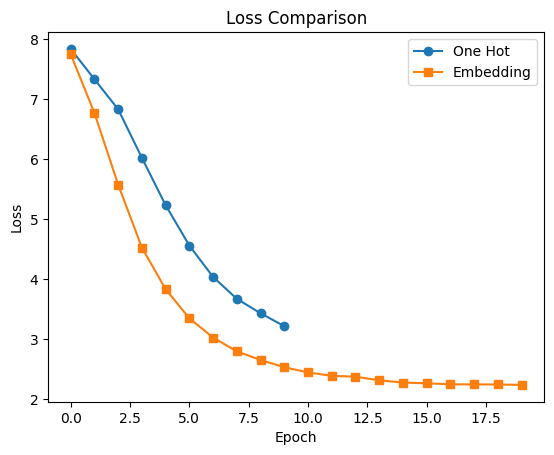

In [32]:
import matplotlib.pyplot as plt

plt.plot(losses_onehot, marker='o', label="One Hot")
plt.plot(losses_embed, marker='s', label="Embedding")
plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



In [33]:
def generate(model, start_word, length=20):
    model.eval()
    words = [start_word]

    input_seq = torch.tensor([[word2idx[start_word]]])

    for _ in range(length):
        output = model(input_seq)
        prob = torch.softmax(output[0, -1], dim=0)
        idx = torch.multinomial(prob, 1).item()

        words.append(idx2word[idx])
        input_seq = torch.tensor([[idx]])

    return " ".join(words)


In [34]:
print("OneHot Generated:\n")
print(generate(model1, "love"))

print("\nEmbedding Generated:\n")
print(generate(model2, "love"))


OneHot Generated:

love is brush a tree and fast, and the same and downy under the moon on a rhyme? grass of you,

Embedding Generated:

love my spirit eyes i said, "he thinks he may be dim, joy outposts of old salt and filter and little
